### Crating a simple workflow for Nodes Edges and States in Lang graph

In [1]:
from typing_extensions import TypedDict

# In Lang graph we need to specify the state (structure)of schema
class State(TypedDict):
    graph_info :str

In [2]:
# Defining the Nodes
def weather_node(state:State):
    print("checking the Weather Status....")
    return {"graph_info":state['graph_info']}
def sunny_node(state:State):
    print("Graph Info")
    return{'graph_info':state['graph_info']+" "+"It's a Sunny Day..."}
def rainy_node(state:State):
    return{"graph_info":state['graph_info']+" "+"It's Raining..."}

In [3]:
import random
from typing import Literal

def random_weather(state:State)-> Literal['sunny_node','rainy_node']:
    grapg_info = state['graph_info']
    if random.random()>0.5:
        return "sunny_node"
    else:
        return "rainy_node"

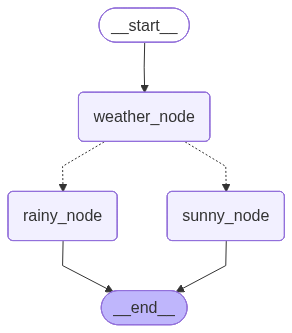

In [4]:
from langgraph.graph import START,END,StateGraph
from IPython.display import Image,display
graph = StateGraph(State)

graph.add_node("weather_node",weather_node)
graph.add_node("sunny_node",sunny_node)
graph.add_node("rainy_node",rainy_node)

graph.add_edge(START,"weather_node")
graph.add_conditional_edges("weather_node",random_weather)
graph.add_edge("sunny_node",END)
graph.add_edge("rainy_node",END)

graph_builder = graph.compile()

display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [12]:
graph_builder.invoke({"graph_info":"Sukesh"})

checking the Weather Status....
Graph Info


{'graph_info': "Sukesh It's a Sunny Day..."}

### simple node graph with an LLM 

In [11]:
import os
from typing import Annotated, TypedDict  # Use standard TypedDict


# LangGraph and LangChain imports
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_groq import ChatGroq
from dotenv import load_dotenv
# Load environment variables
load_dotenv()

True

In [13]:
class State(TypedDict):
    messages:Annotated[list,add_messages]

In [14]:
llm = ChatGroq(model = "qwen/qwen3-32b",api_key = os.getenv("GROQ_API_KEY"))

llm.invoke("I am a Hero I like Marvel Movies")

AIMessage(content="<think>\nOkay, the user mentioned they're a hero and like Marvel movies. Let me start by acknowledging their self-identification as a hero. That's a strong statement, so I should respond with enthusiasm and respect.\n\nFirst, I need to connect their identity as a hero with their love for Marvel. Maybe they see themselves as a real-life hero, or they admire the characters in the movies. Either way, it's a good opportunity to relate their personal traits to the stories they enjoy.\n\nI should mention specific Marvel characters that embody heroism, like Iron Man, Captain America, or Thor. These are iconic figures who have faced challenges and grown as heroes. Highlighting their journeys can create a deeper connection.\n\nAlso, the user might appreciate knowing that Marvel heroes often have flaws but overcome them through courage and teamwork. This can mirror real-life situations where perseverance leads to success. I should emphasize the themes of resilience and doing w

In [15]:
def chatbot(state:State):
    return{"messages":[llm.invoke(state['messages'])]}

In [16]:
graph = StateGraph(State)

graph.add_node("chatbot",chatbot)

graph.add_edge(START,"chatbot")
graph.add_edge("chatbot",END)

graph_builder = graph.compile()
graph_builder.invoke({'messages': "HI I am a Hero I like Marvel Movies"})

{'messages': [HumanMessage(content='HI I am a Hero I like Marvel Movies', additional_kwargs={}, response_metadata={}, id='9b5e3775-5a75-4174-93f4-8ea8b8aa147e'),
  AIMessage(content='<think>\nOkay, so the user says, "HI I am a Hero I like Marvel Movies." First, I need to figure out the best way to respond. They mentioned being a hero and liking Marvel movies. Maybe they\'re a fan of characters like Iron Man or Captain America. But the way they wrote it is a bit confusing. "I am a Hero" could be a typo, maybe they meant "I am a hero" or "I\'m a hero." Or maybe they\'re referring to the movie "I Am a Hero," which is a Japanese film. But they also mentioned Marvel movies, so maybe they\'re a fan of Marvel heroes.\n\nI should start by acknowledging their statement. It\'s possible they\'re role-playing as a hero or just expressing their admiration for Marvel characters. I need to ask for clarification to make sure I understand correctly. Maybe they want to discuss their favorite Marvel movi

In [17]:
graph_builder.invoke({'messages': "HI I Travelling"})

{'messages': [HumanMessage(content='HI I Travelling', additional_kwargs={}, response_metadata={}, id='17e9df7f-a35c-4703-aaf5-db8f13202192'),
  AIMessage(content='<think>\nOkay, the user said, "HI I Travelling." Let me see. First, I need to respond appropriately. The greeting is friendly, so I should keep the tone positive. Maybe start with a greeting like "Hello!" or "Hi there!".\n\nNext, the user mentioned traveling. I should ask a question to engage them more. Maybe something like, "Where are you going? I\'d love to hear about your travel plans!" That way, it invites them to share more details.\n\nWait, did they make a typo? "Travelling" is the British spelling, but maybe they meant "am traveling" or "I am travelling." Should I correct that? Probably not necessary; just respond naturally. If they use the British spelling, I can match it.\n\nAlso, maybe they want to discuss travel tips, destinations, or experiences. I should keep the response open-ended to let them guide the conversa

In [18]:
graph_builder.invoke({"messages":"Who am I?"})

{'messages': [HumanMessage(content='Who am I?', additional_kwargs={}, response_metadata={}, id='7c5760b5-2fcb-4d43-ba4e-86dea90e0486'),
  AIMessage(content='<think>\nOkay, the user is asking "Who am I?" which is a bit ambiguous. Let me think about how to approach this.\n\nFirst, they might be asking about their own identity, maybe in a philosophical or existential sense. Or they could be asking about their identity in the context of the conversation. Since they\'re interacting with me, the AI, maybe they want to know their role here. \n\nI should consider different possibilities. If it\'s a philosophical question, I can explain that identity is a complex topic. If they\'re asking about how I perceive them, I can mention that I treat all users as equal and value their privacy. Also, maybe they\'re confused about their online identity, so reassuring them about privacy and anonymity is important.\n\nI need to make sure my response is helpful and covers possible interpretations. I should a